<a href="https://colab.research.google.com/github/bakenova/Find-out-related-concepts-for-the-Machine-Learning---Generate-Image/blob/main/TextConceptsML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Find out related concepts for the Machine Learning - Generate Image

This notebook extracts machine learning-related content from a website,
analyzes word frequencies, and creates visualizations including word clouds
and bar chart.

Import all necessary libraries for web scraping, text processing,
data manipulation, and visualization

In [2]:
import sys
!{sys.executable} -m pip install beautifulsoup4
!{sys.executable} -m pip install nlp_rake

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 14.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.3/122.3 kB 7.7 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=a835ed991f9332cffd427011bd0cae4142ab0d578756f027999471d7fccaf567
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [3]:
import requests
from bs4 import BeautifulSoup
from nlp_rake import Rake
from nlp_rake.utils import separate_words
from matplotlib import pyplot as plt
from wordcloud import WordCloud

Target URL for scraping (Machine Learning article from IBM). Send HTTP request and decode the page content

In [4]:
url = 'https://www.ibm.com/think/topics/machine-learning'

text = requests.get(url).content.decode('utf-8')
print(text[:1000])

 
<!DOCTYPE HTML>

<html lang="en">
<head>
    
    
    
    
    
    
    
      
    
    
    
    
    <meta charset="UTF-8"/>
    <meta name="languageCode" content="en"/>
    <meta name="countryCode" content="us"/>
    <meta name="searchTitle" content="What is Machine Learning?"/>
    <meta name="focusArea" content="Data AI - All"/>
    <meta name='primaryTaxonomyEn' content="Machine learning"/>
    <meta name="siteSection" content="think"/>
    <meta name="primaryTopic" content="Machine learning"/>
    <meta name="productName"/>
    <meta name="pageType" content="Learn - Topics - Definition"/>
    <title>What is Machine Learning? | IBM </title>
      <meta name="content-page-ref" content="eROxip4tByGTXXkYPHZou-BiuGJ9_RYmtHfVzsWttQOhqB9PhDZeqIbMbPFwAfZafgMcMzhTaissJItRrM5xQdMKpSUHSC29pU0w0gp7y6M"/>
<script defer="defer" type="text/javascript" src="https://rum.hlx.page/.rum/@adobe/helix-rum-js@%5E2/dist/micro.js" data-routing="program=131558,environment=12


Parse HTML content using BeautifulSoup. Extract main content container and define function to remove unnecessary HTML elements (navigation, references, etc.), then remove unwanted elements.

In [5]:
soup = BeautifulSoup(text, 'html.parser')
content = soup.find('div', class_ = 'cmp-container')

def clean_content(content_node):
  selectors = [
      '.mw-jump-link',
        '.navbox',
        '.reflist',
        'sup.reference',
        '.mw-editsection',
        '.hatnote',
        '.metadata',
        '.infobox',
        '#toc',
        '.toc',
        '.sidebar'
        ]
  for selector in selectors:
    for element in content_node.select(selector):
      element.decompose()

if content:
  clean_content(content)
  text = content.get_text(separator = ' ', strip = True)
  print(text[: 1000])
else:
  print('No content found')
  text = soup.get_text(separator = ' ', strip = True)
  print(text[:1000])

What is machine learning? Machine learning Welcome Caret right Introduction Overview Machine learning types Machine learning algorithms Caret right Data science for machine learning Statistical machine learning Linear algebra for machine learning Uncertainty quantification Bias variance tradeoff Bayesian Statistics Singular value decomposition Caret right Feature Engineering Overview Feature selection Feature extraction Vector embedding Latent space Caret right Dimensionality reduction Principal component analysis Linear discriminant analysis Upsampling Downsampling Synthetic data Data leakage Caret right Supervised learning Overview Caret right Regression Linear regression Lasso regression Ridge regression State space model Time series Autoregressive model Caret right Classification Overview Decision trees K-nearest neighbors (KNNs) Naive bayes Random forest Support vector machine Logistic regression Caret right Ensemble learning Overview Boosting Bagging Gradient boosting Gradient bo

Initialize RAKE keyword extractor with constraints. Extract keywords and their scores

In [6]:
extractor = Rake(max_words=2, min_freq=3, min_chars=5)
res = extractor.apply(text)
res

[('artificial intelligence', 4.0),
 ('data points', 4.0),
 ('data modalities', 4.0),
 ('ground truth', 4.0),
 ('unlabeled data', 4.0),
 ('reinforcement learning', 3.983050847457627),
 ('self-supervised learning', 3.983050847457627),
 ('machine learning', 3.94601381042059),
 ('training data', 3.8),
 ('labeled data', 3.8),
 ('neural networks', 3.8),
 ('supervised learning', 3.7522816166883963),
 ('loss function', 3.6923076923076925),
 ('training', 1.8),
 ('supervised', 1.7692307692307692),
 ('function', 1.6923076923076923),
 ('models', 1.5555555555555556),
 ('model', 1.5454545454545454),
 ('input', 1.5),
 ('number', 1.5),
 ('state', 1.5),
 ('tasks', 1.4166666666666667),
 ('algorithm', 1.4),
 ('process', 1.4),
 ('classification', 1.4),
 ('trained', 1.4),
 ('output', 1.2857142857142858),
 ('action', 1.2857142857142858),
 ('dataset', 1.25),
 ('optimizing', 1.25),
 ('correct', 1.25),
 ('optimized', 1.25),
 ('they’re', 1.25),
 ('build', 1.2),
 ('policy', 1.2),
 ('mlops', 1.2),
 ('learn', 1.0)

Function to plot keyword frequencies as a bar chart

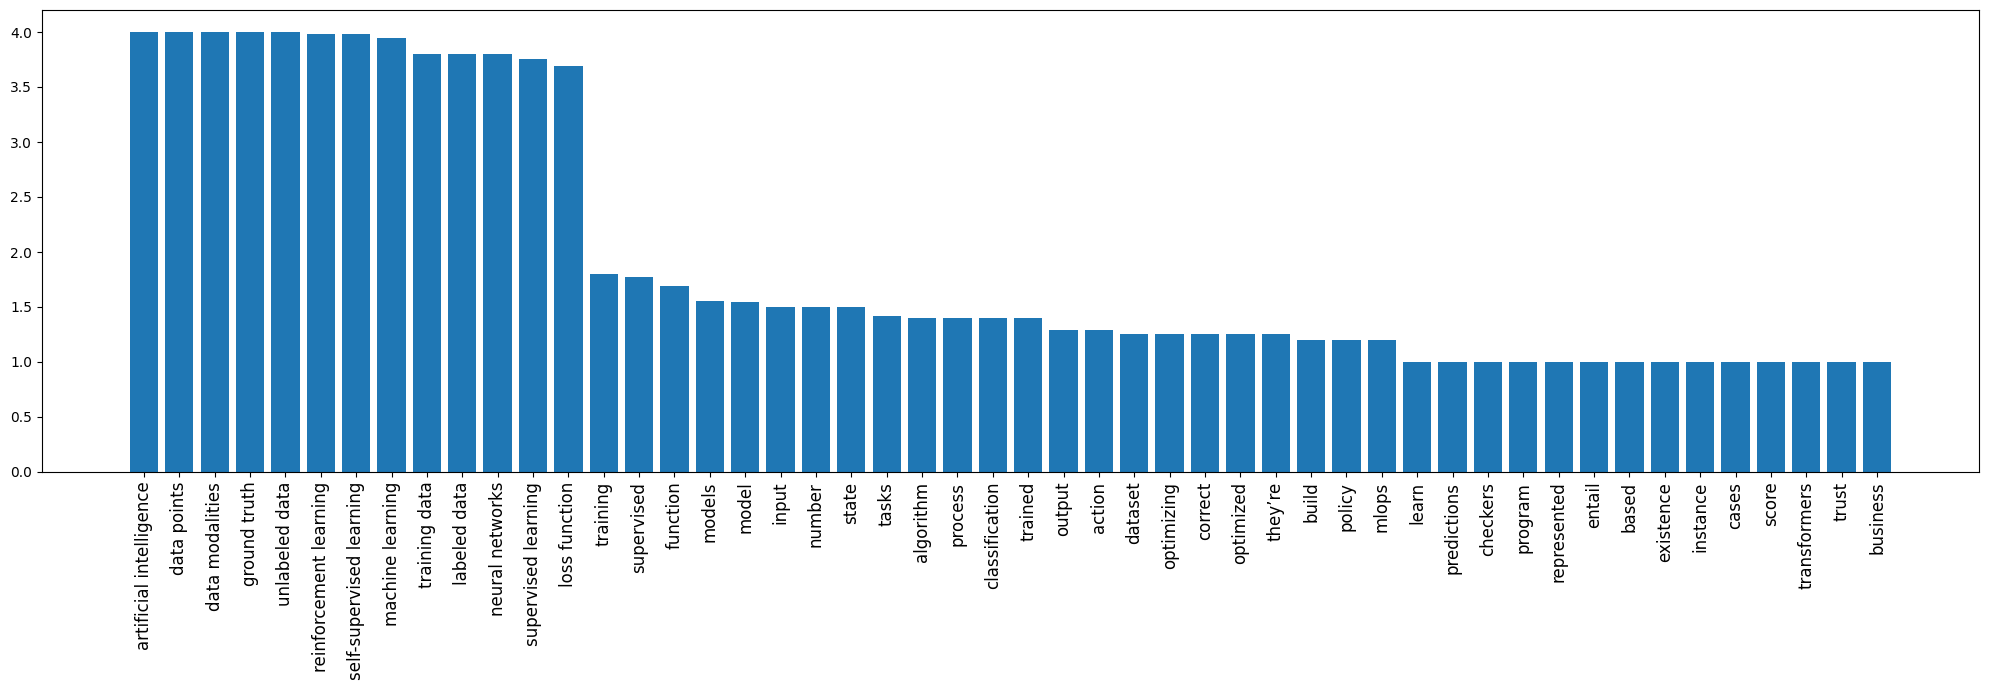

In [7]:
def plot(pair_list):
  k,v = zip(*pair_list)

  num_categories = len(pair_list)
  width = max(10, num_categories * 0.5)
  plt.figure(figsize = (width, 6))

  plt.bar(range(len(pair_list)), v)
  plt.xticks(range(len(k)), k, rotation = 'vertical', fontsize = 12)
  plt.show()

plot(res)

Create a word cloud based on keyword frequencies.

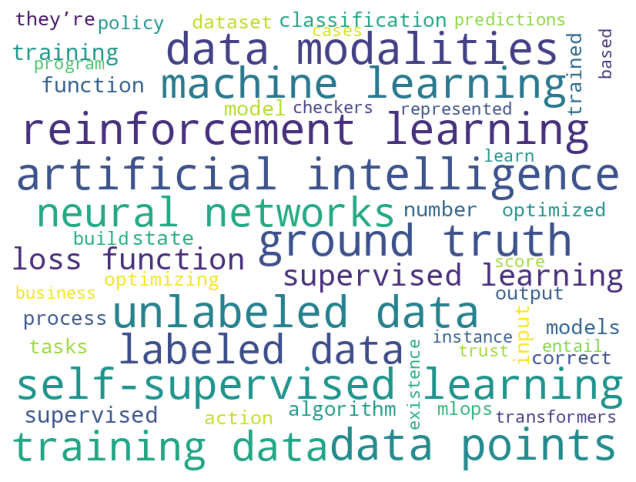

In [8]:
wc = WordCloud(background_color = 'white', width = 800, height = 600)
plt.figure(figsize = (10, 6))
plt.imshow(wc.generate_from_frequencies({k:v for k,v in res}))
plt.axis('off')
plt.show()

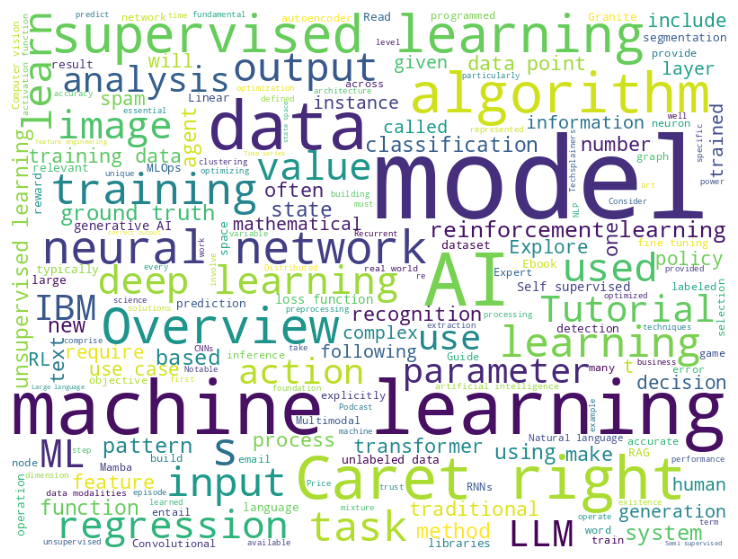

In [9]:
plt.figure(figsize=(15,7))
plt.imshow(wc.generate(text))
plt.axis('off')
plt.show()

Create a word cloud based on keyword frequencies

In [11]:
wc.generate(text).to_file('images/ml_wordcloud.png')